In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from dstapi import DstApi
from scipy import optimize

import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.rcParams.update({
    'axes.grid': True,
    'grid.color': 'black',
    'grid.alpha': 0.25,
    'grid.linestyle': '--'
})

plt.rcParams.update({'font.size': 14})

In [2]:
#%pip install git+https://github.com/alemartinello/dstapi

# Data Analysis Project

## 1. Inequality in Denmark

### 1.1 The Gini coefficient and the top 10 percent share

In [3]:
# a. setup table
IFOR41 = DstApi('IFOR41')

# b. overview of table
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [4]:
# a. set download parameters
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

# b. download data
gini = IFOR41.get_data(params=params)

# c. show first observations
gini.head()

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


In [5]:
# d. clean data

# replace missing values with NaN
I = gini['INDHOLD'] == '..'
gini.loc[I, 'INDHOLD'] = 'nan'

# convert variable types
gini['TID'] = gini['TID'].astype(int)
gini['INDHOLD'] = gini['INDHOLD'].astype(float)

# drop unnecessary variables
gini = gini.drop(columns=['ULLIG', 'KOMMUNEDK'])

# rename variables
gini = gini.rename(columns={
    'TID': 'year',
    'INDHOLD': 'gini'
})

# sort by year
gini = gini.sort_values('year').reset_index(drop=True)

gini.head()

,year,gini
0,1987,22.07
1,1988,22.06
2,1989,21.93
3,1990,22.16
4,1991,21.99


In [6]:
# e. verify data
gini.info()
gini.describe()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    38 non-null     int64  
 1   gini    38 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 740.0 bytes


,year,gini
count,38.000000,38.000000
mean,2005.500000,25.918421
std,11.113055,2.972756
min,1987.000000,21.930000
25%,1996.250000,22.990000
50%,2005.500000,25.970000
75%,2014.750000,28.660000
max,2024.000000,30.610000


In [7]:
gini.tail()

,year,gini
33,2020,29.72
34,2021,30.28
35,2022,29.96
36,2023,30.61
37,2024,30.43


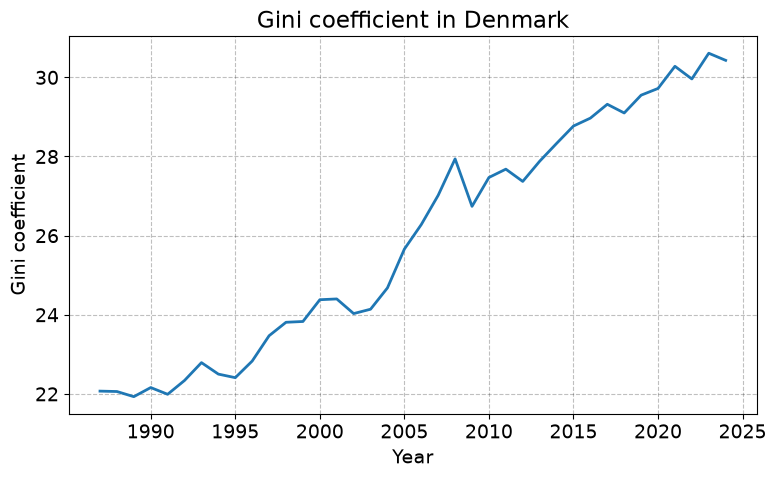

In [8]:
# f. plot Gini coefficient

fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

ax.plot(gini['year'], gini['gini'], lw=2)

ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

fig.tight_layout()

In [9]:
# g. setup table for income deciles
IFOR32 = DstApi('IFOR32')

# h. overview of table
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [10]:
# i. set download parameters
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

# j. download data
deciles = IFOR32.get_data(params=params)

# k. show first observations
deciles.head()

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,First decil,All Denmark,2013,75704
1,Second decil,All Denmark,2013,140049
2,Third decil,All Denmark,2013,163582
3,Fourth decil,All Denmark,2013,185931
4,Fifth decil,All Denmark,2013,209384


In [12]:
# l. clean decile data

# a. convert variable types
deciles['TID'] = deciles['TID'].astype(int)
deciles['INDHOLD'] = deciles['INDHOLD'].astype(float)

# b. drop unnecessary variable
deciles = deciles.drop(columns=['KOMMUNEDK'])

# c. rename variables
deciles = deciles.rename(columns={
    'DECILGEN': 'decile',
    'TID': 'year',
    'INDHOLD': 'income'
})

# d. sort by year
deciles = deciles.sort_values('year').reset_index(drop=True)

# e. show first observations
deciles.head(10)

,decile,year,income
0,First decil,1987,31418.0
1,Ninth decil,1987,123582.0
2,Eigth decil,1987,110184.0
3,Seventh decil,1987,100691.0
4,Sixth decil,1987,92777.0
5,Fifth decil,1987,85361.0
6,Fourth decil,1987,77577.0
7,Third decil,1987,68786.0
8,Second decil,1987,59014.0
9,Tenth decil,1987,169598.0


In [13]:
# m. verify decile data

deciles.info()
deciles.describe()

print(deciles['decile'].unique())
print(f'Number of observations: {len(deciles)}')

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   decile  380 non-null    str    
 1   year    380 non-null    int64  
 2   income  380 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 13.3 KB
<ArrowStringArray>
[  'First decil',   'Ninth decil',   'Eigth decil', 'Seventh decil',
   'Sixth decil',   'Fifth decil',  'Fourth decil',   'Third decil',
  'Second decil',   'Tenth decil']
Length: 10, dtype: str
Number of observations: 380


In [14]:
# n. calculate top 10 percent income share

# a. calculate total income across deciles within each year
deciles['total_income'] = (
    deciles.groupby('year')['income'].transform('sum')
)

# b. calculate income share for each decile
deciles['income_share'] = (
    deciles['income'] / deciles['total_income']
)

# c. select the tenth decile
I = deciles['decile'] == 'Tenth decil'

top10 = deciles.loc[I, ['year', 'income_share']].copy()

# d. rename variable
top10 = top10.rename(columns={
    'income_share': 'top10_share'
})

# e. convert share to percent
top10['top10_share'] = 100 * top10['top10_share']

# f. sort by year
top10 = top10.sort_values('year').reset_index(drop=True)

top10.head()

,year,top10_share
0,1987,18.454866
1,1988,18.428870
2,1989,18.495170
3,1990,18.641480
4,1991,18.668346


In [15]:
# o. merge inequality measures

# a. merge Gini coefficient and top 10 percent share
inequality = pd.merge(
    gini,
    top10,
    on='year',
    how='inner'
)

# b. show first observations
inequality.head()

,year,gini,top10_share
0,1987,22.07,18.454866
1,1988,22.06,18.428870
2,1989,21.93,18.495170
3,1990,22.16,18.641480
4,1991,21.99,18.668346


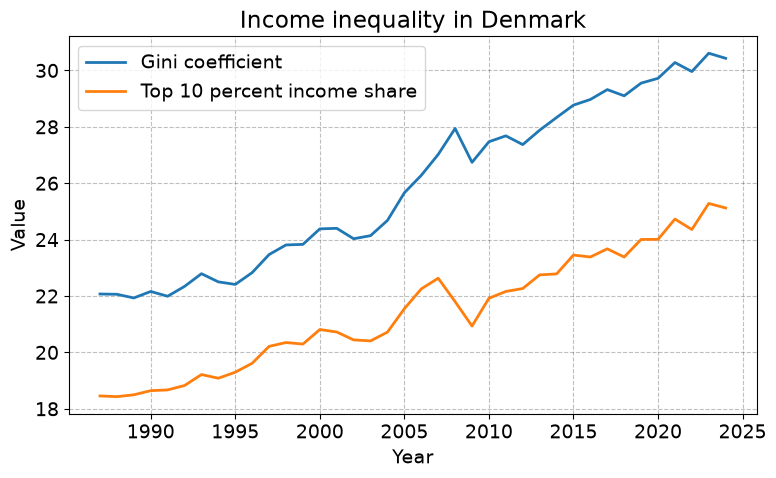

In [19]:
# p. plot inequality measures

fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

# a. plot both measures
ax.plot(
    inequality['year'],
    inequality['gini'],
    lw=2,
    label='Gini coefficient'
)

ax.plot(
    inequality['year'],
    inequality['top10_share'],
    lw=2,
    label='Top 10 percent income share'
)

# b. labels
ax.set_title('Income inequality in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Value')

# c. legend
ax.legend()

fig.tight_layout()

In [17]:
# q. calculate correlation

corr = inequality['gini'].corr(
    inequality['top10_share']
)

print(f'Correlation between the two inequality measures: {corr:.3f}')

Correlation between the two inequality measures: 0.982


#### Discussion

Income inequality in Denmark has increased substantially since 1987. 
The Gini coefficient increased from approximately 22 in 1987 to above 
30 in 2024. Similarly, the income share of the richest 10 percent 
increased from approximately 18.5 percent to around 25 percent.

The two measures therefore tell a very similar story. Both indicate a 
general increase in income inequality over the period, although there 
are some temporary fluctuations. In particular, both measures decline 
around 2009 before continuing their upward trend.

The correlation between the Gini coefficient and the top 10 percent 
income share is 0.982. This indicates a very strong positive relationship 
between the two measures over time.

### 1.2 Prediction

We fit a linear and a quadratic trend to the Gini coefficient using
least squares. The models are estimated using `scipy.optimize.minimize`
and subsequently checked against `np.polyfit`.

In [20]:
# a. prepare data

# number of years since 1987
t = gini['year'].to_numpy() - 1987

# Gini coefficient
y = gini['gini'].to_numpy()

# show first observations
print(t[:5])
print(y[:5])

[0 1 2 3 4]
[22.07 22.06 21.93 22.16 21.99]


In [21]:
# b. define objective function

def objective(beta, t, y):
    """Calculate the sum of squared residuals for a polynomial trend."""
    
    # i. initialize predicted values
    y_hat = np.zeros(len(t))
    
    # ii. calculate polynomial prediction
    for k in range(len(beta)):
        y_hat += beta[k] * t**k
    
    # iii. calculate residuals
    residuals = y - y_hat
    
    # iv. return sum of squared residuals
    return np.sum(residuals**2)

In [24]:
# c. estimate linear and quadratic trends

# a. initial guesses
beta0_linear = np.array([20.0, 0.0])
beta0_quadratic = np.array([20.0, 0.0, 0.0])

# b. estimate linear trend
sol_linear = optimize.minimize(
    objective,
    beta0_linear,
    args=(t, y),
    method='Nelder-Mead'
)

# c. estimate quadratic trend
sol_quadratic = optimize.minimize(
    objective,
    beta0_quadratic,
    args=(t, y),
    method='Nelder-Mead'
)

# d. extract estimated coefficients
beta_linear = sol_linear.x
beta_quadratic = sol_quadratic.x

# e. print results
print('Linear trend:')
print(f'Success: {sol_linear.success}')
print(f'beta0 = {beta_linear[0]:.4f}')
print(f'beta1 = {beta_linear[1]:.4f}')

print('')

print('Quadratic trend:')
print(f'Success: {sol_quadratic.success}')
print(f'beta0 = {beta_quadratic[0]:.4f}')
print(f'beta1 = {beta_quadratic[1]:.4f}')
print(f'beta2 = {beta_quadratic[2]:.6f}')

Linear trend:
Success: True
beta0 = 21.0427
beta1 = 0.2636

Quadratic trend:
Success: True
beta0 = 21.3042
beta1 = 0.2200
beta2 = 0.001178


In [25]:
# d. inspect optimization results

print('Linear trend:')
print(sol_linear.message)

print('')

print('Quadratic trend:')
print(sol_quadratic.message)

Linear trend:
Optimization terminated successfully.

Quadratic trend:
Optimization terminated successfully.


In [26]:
# d. check estimates with np.polyfit

# a. estimate linear trend with np.polyfit
polyfit_linear = np.polyfit(t, y, 1)

# b. estimate quadratic trend with np.polyfit
polyfit_quadratic = np.polyfit(t, y, 2)

# c. reorder coefficients to match our own notation
beta_linear_polyfit = np.array([
    polyfit_linear[1],
    polyfit_linear[0]
])

beta_quadratic_polyfit = np.array([
    polyfit_quadratic[2],
    polyfit_quadratic[1],
    polyfit_quadratic[0]
])

# d. print comparison
print('Linear trend:')
print('Minimize:', beta_linear)
print('Polyfit: ', beta_linear_polyfit)

print('')

print('Quadratic trend:')
print('Minimize:', beta_quadratic)
print('Polyfit: ', beta_quadratic_polyfit)

# e. check whether coefficients are approximately equal
print('')
print('Linear coefficients match:',
      np.allclose(beta_linear, beta_linear_polyfit, atol=1e-4))

print('Quadratic coefficients match:',
      np.allclose(beta_quadratic, beta_quadratic_polyfit, atol=1e-4))

Linear trend:
Minimize: [21.04272868  0.26355106]
Polyfit:  [21.04275304  0.26354962]

Quadratic trend:
Minimize: [2.13041998e+01 2.19977038e-01 1.17760240e-03]
Polyfit:  [2.13042004e+01 2.19975061e-01 1.17769085e-03]

Linear coefficients match: True
Quadratic coefficients match: True


In [27]:
# e. predict Gini coefficient in 2030 and 2040

# a. years to predict
future_years = np.array([2030, 2040])

# b. convert calendar years to years since 1987
# 1987 corresponds to t = 0 in our model
t_future = future_years - 1987

# c. predictions from the linear trend
gini_linear_future = (
    beta_linear[0]
    + beta_linear[1] * t_future
)

# d. predictions from the quadratic trend
gini_quadratic_future = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_future
    + beta_quadratic[2] * t_future**2
)

# e. print predictions
for i, year in enumerate(future_years):
    print(f'Year {year}:')
    print(f'Linear prediction = {gini_linear_future[i]:.2f}')
    print(f'Quadratic prediction = {gini_quadratic_future[i]:.2f}')
    print('')

Year 2030:
Linear prediction = 32.38
Quadratic prediction = 32.94

Year 2040:
Linear prediction = 35.01
Quadratic prediction = 36.27



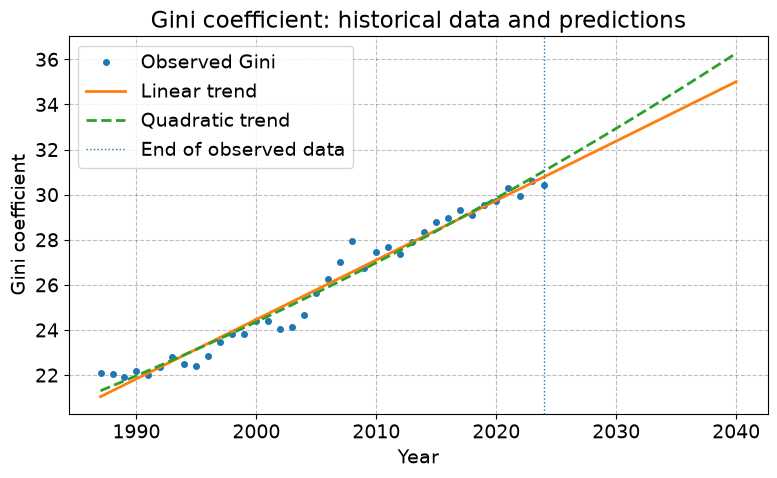

In [28]:
# f. plot historical data and predictions

# a. create years from 1987 to 2040
years_plot = np.arange(1987, 2041)

# b. convert years to years since 1987
t_plot = years_plot - 1987

# c. calculate fitted and predicted values
gini_linear_plot = (
    beta_linear[0]
    + beta_linear[1] * t_plot
)

gini_quadratic_plot = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_plot
    + beta_quadratic[2] * t_plot**2
)

# d. create figure
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

# e. plot historical Gini observations
ax.plot(
    gini['year'],
    gini['gini'],
    ls='',
    marker='o',
    markersize=4,
    label='Observed Gini'
)

# f. plot linear trend
ax.plot(
    years_plot,
    gini_linear_plot,
    lw=2,
    label='Linear trend'
)

# g. plot quadratic trend
ax.plot(
    years_plot,
    gini_quadratic_plot,
    lw=2,
    ls='--',
    label='Quadratic trend'
)

# h. indicate where prediction period begins
ax.axvline(
    2024,
    lw=1,
    ls=':',
    label='End of observed data'
)

# i. labels
ax.set_title('Gini coefficient: historical data and predictions')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

# j. legend
ax.legend()

fig.tight_layout()

In [29]:
# g. evaluate historical fit

# a. fitted values for the historical period
gini_linear_fitted = (
    beta_linear[0]
    + beta_linear[1] * t
)

gini_quadratic_fitted = (
    beta_quadratic[0]
    + beta_quadratic[1] * t
    + beta_quadratic[2] * t**2
)

# b. calculate residuals
residuals_linear = y - gini_linear_fitted
residuals_quadratic = y - gini_quadratic_fitted

# c. calculate sum of squared residuals
sse_linear = np.sum(residuals_linear**2)
sse_quadratic = np.sum(residuals_quadratic**2)

# d. calculate root mean squared error
rmse_linear = np.sqrt(np.mean(residuals_linear**2))
rmse_quadratic = np.sqrt(np.mean(residuals_quadratic**2))

# e. print results
print('Historical fit:')
print(f'Linear SSE = {sse_linear:.3f}')
print(f'Quadratic SSE = {sse_quadratic:.3f}')
print('')
print(f'Linear RMSE = {rmse_linear:.3f}')
print(f'Quadratic RMSE = {rmse_quadratic:.3f}')

Historical fit:
Linear SSE = 9.589
Quadratic SSE = 8.981

Linear RMSE = 0.502
Quadratic RMSE = 0.486


#### Discussion

Both the linear and the quadratic trend fit the historical Gini data
reasonably well. The linear model has an RMSE of 0.502, while the
quadratic model has a slightly lower RMSE of 0.486. This suggests that
the quadratic specification provides a marginally better fit to the
historical data.

The two models give relatively similar predictions for 2030. The linear
model predicts a Gini coefficient of 32.38, while the quadratic model
predicts 32.94. The difference is therefore 0.56 Gini points.

By 2040, the predictions differ more. The linear model predicts 35.01,
while the quadratic model predicts 36.27, corresponding to a difference
of 1.26 Gini points. The predictions therefore become more sensitive to
the chosen functional form as the forecast horizon increases.

Neither prediction should be interpreted as a precise forecast of future
inequality. Both models simply extrapolate historical trends and do not
take into account future changes in, for example, taxes, transfers,
labour markets or the broader economy. The quadratic model fits the
historical data slightly better, but its curvature also makes long-run
predictions more sensitive. I would therefore be cautious when using
either model for long-term forecasting.